In [ ]:
import typing

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from flowjax.train import fit_to_data
from flowjax.flows import masked_autoregressive_flow

import jax.random as jr

from flowjax.train.losses import MaximumLikelihoodLoss
from flowjax.bijections import RationalQuadraticSpline
from flowjax.distributions import Normal

from petra import make_catalog_mv_normal
from petra import PosteriorChain

from scipy.stats import kstest

import corner
import matplotlib.patches as mpatches

jax.config.update('jax_enable_x64', False)

PyTree = typing.Any

In [2]:
posterior_chain = PosteriorChain.read_feather('./lisa_example.feather')
relabeled_chain = make_catalog_mv_normal(posterior_chain, posterior_chain.num_sources, initialization_param_index=0)

Initializing with univariate normal distribution.

Sorting the posterior chain:
	Maximum number of iterations: 200
	Maximum number of source labels:20

Fewer than 8 values in source index 4. Appending normal distribution fit to all entries.
Iteration 1: Difference in cost of assignment is -114.59924532361896 with total cost of -114.59924532361896.
	Probabilities in model: [0.99   0.99   0.99   0.024  0.01   0.8665 0.99   0.99   0.99   0.362
 0.0965 0.99   0.1325 0.99   0.6145 0.217  0.7095 0.601  0.99   0.99  ]
Fewer than 8 values in source index 4. Appending normal distribution fit to all entries.
Iteration 2: Difference in cost of assignment is -49.5701513562712 with total cost of -164.16939667989016.
	Probabilities in model: [0.99   0.99   0.99   0.018  0.01   0.845  0.99   0.99   0.99   0.404
 0.0965 0.99   0.299  0.99   0.4605 0.37   0.4655 0.6645 0.99   0.99  ]
Fewer than 8 values in source index 4. Appending normal distribution fit to all entries.
Iteration 3: Difference in cost

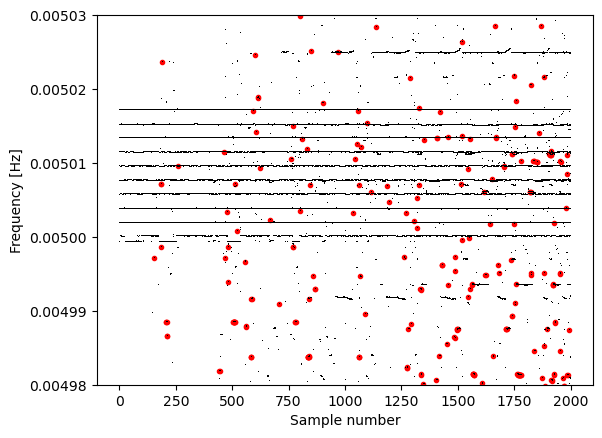

In [ ]:
# highlight the samples in red associated with this catalog source
result_index = 4
plt.plot(relabeled_chain.chain[:, result_index, 0], 'r.')

for i in range(posterior_chain.chain.shape[1]):
    plt.plot(posterior_chain.chain[:, i, 0], 'k,')

plt.xlabel('Sample number')
plt.ylabel('Frequency [Hz]')
plt.ylim(0.00498, 0.00503)
plt.show()

In [46]:
sample = relabeled_chain[:, result_index, :]

In [47]:
x = sample
# remove nans
if np.isnan(x).any():
    x = x[~np.isnan(x).any(axis=1)]  # Remove rows with NaNs
x = (x - x.mean(axis=0)) / x.std(axis=0)  # Standardize

In [48]:
p_values = []
for dim in range(x.shape[1]):
    data = x[:, dim]
    lower = data.min()
    width = data.max() - lower
    stat, p_value = kstest(data, 'uniform', args=(lower, width))
    # print(f"Axis {dim}: KS statistic = {stat:.4f}, p-value = {p_value:.4f}")
    p_values.append(p_value)
uniform_idxs = np.where(np.array(p_values) < 3e-7)[0]  # Find dimensions with p-value > 5 sigma

In [49]:
# remove uniform dimensions
x = x[:, uniform_idxs]

 13%|█▎        | 67/500 [00:06<00:41, 10.51it/s, train=3.87, val=5.63 (Max patience reached)]


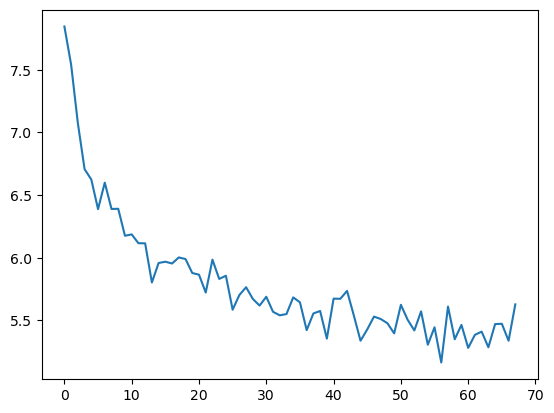

In [ ]:
loss_fn = MaximumLikelihoodLoss()

key, subkey = jr.split(jr.key(0))

# flow = masked_autoregressive_flow(
#     subkey,
#     base_dist=Normal(jnp.zeros(x.shape[1])),
#     transformer=RationalQuadraticSpline(knots=64, interval=8),
#     invert=True,
#     flow_layers=16,
#     nn_width=50,
#     nn_depth=8
# )

flow = masked_autoregressive_flow(
    subkey,
    base_dist=Normal(jnp.zeros(x.shape[1])),
    transformer=RationalQuadraticSpline(knots=32, interval=8),
    invert=True,
    # flow_layers=16,
    # nn_width=50,
    # nn_depth=8
)

key, subkey = jr.split(key)
flow, losses = fit_to_data(subkey, flow, x, learning_rate=5e-4, loss_fn=loss_fn, max_epochs=500, batch_size=64, max_patience=10)

plt.plot(losses['val'])

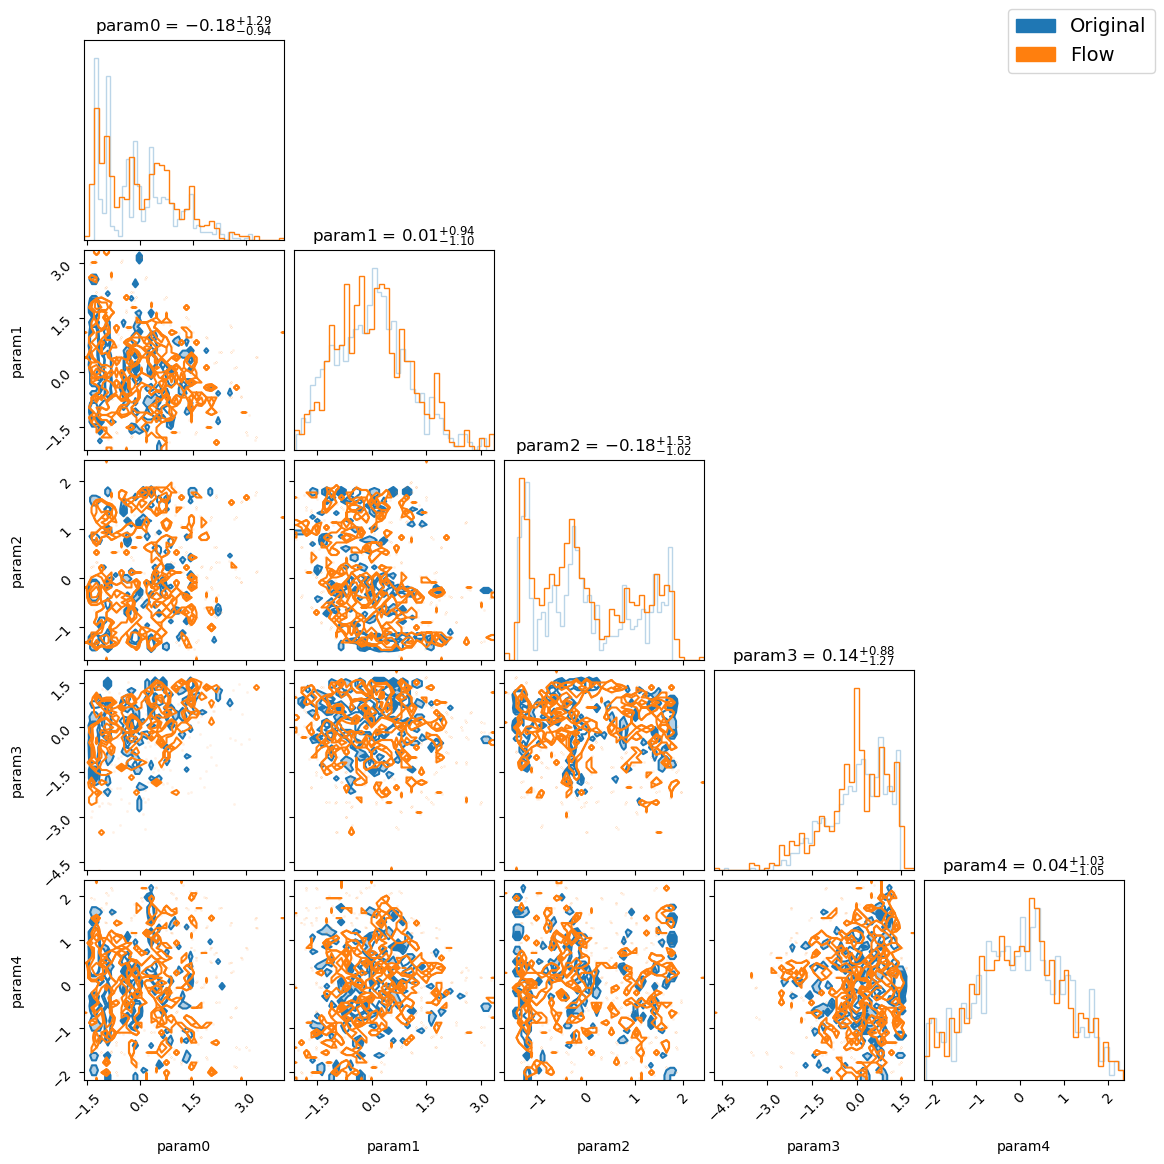

In [51]:
n_samples = len(x)
key, subkey = jax.random.split(key)
x_samples = flow.sample(subkey, (n_samples,))

# assume `x` is your original (N, D) array and `x_samples` is the flow samples (M, D)
labels = [f"param{i}" for i in range(x.shape[1])]

shared_bins = 40
ranges = [(float(x[:, i].min()), float(x[:, i].max())) for i in range(x.shape[1])]

# 1) Draw the original samples in blue
fig = corner.corner(
    x,
    labels=labels,
    color="C0",
    bins=shared_bins,
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.5, 0.9],
    show_titles=True,
    title_fmt=".2f",
    hist_kwargs={"alpha": 0.3},
)

# 2) Overlay the flow samples in red
corner.corner(
    np.array(x_samples),
    fig=fig,
    labels=labels,
    color="C1",
    bins=shared_bins,
    plot_datapoints=True,
    fill_contours=False,
    plot_density=False,
)

# 3) Add a legend
orig_patch = mpatches.Patch(color="C0", label="Original")
flow_patch = mpatches.Patch(color="C1", label="Flow")
fig.legend(handles=[orig_patch, flow_patch], loc="upper right", fontsize=14)

plt.show()

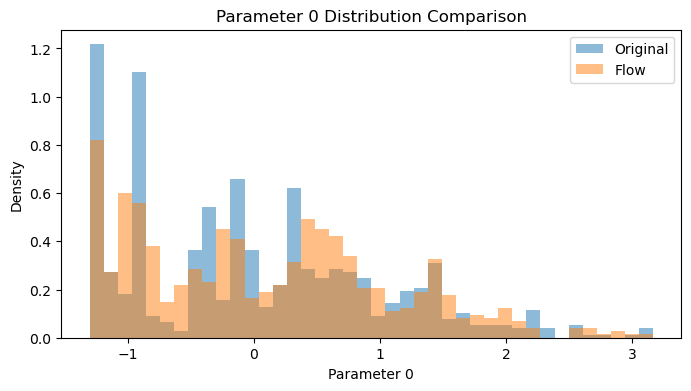

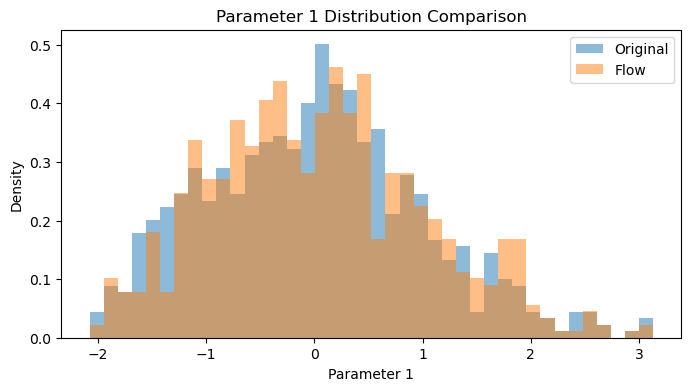

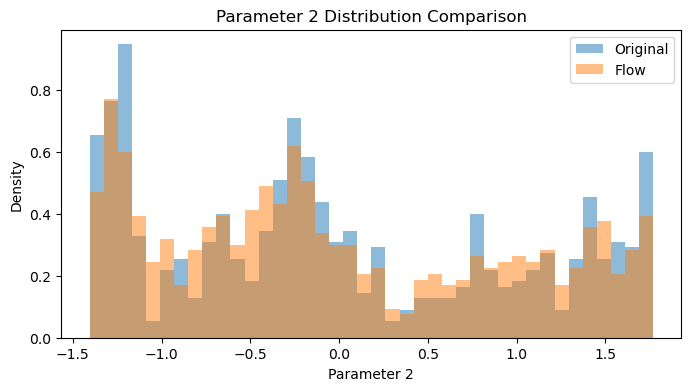

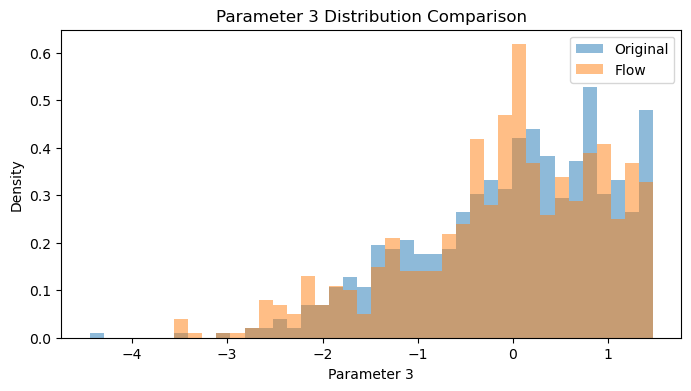

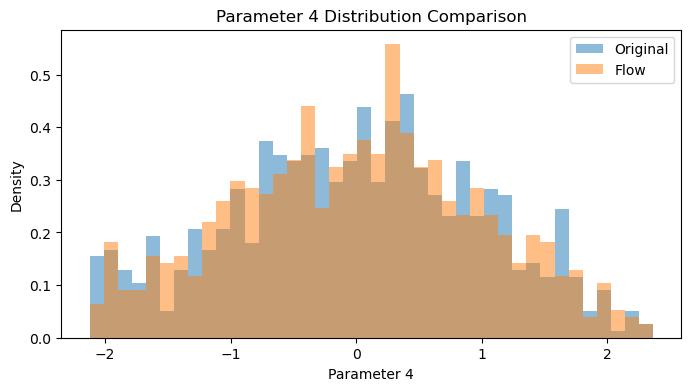

In [52]:
for i in range(x.shape[1]):
    plt.figure(figsize=(8, 4))
    counts, bins, __ = plt.hist(x[:, i], bins=shared_bins, density=True, alpha=0.5, label='Original', color='C0')
    plt.hist(x_samples[:, i], bins=bins, density=True, alpha=0.5, label='Flow', color='C1')
    plt.xlabel(f'Parameter {i}')
    plt.ylabel('Density')
    plt.title(f'Parameter {i} Distribution Comparison')
    plt.legend()
    plt.show()

In [270]:
res

(array([0.17979175, 0.29578643, 0.30738589, 0.38278243, 0.17979175,
        0.0173992 , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.04059814, 0.30158616, 0.84096141,
        1.58332734, 2.58088156, 2.83606985, 1.44413373, 0.23198935]),
 array([-2.90137334, -2.81226652, -2.72315969, -2.63405287, -2.54494604,
        -2.45583922, -2.3667324 , -2.27762557, -2.18851875, -2.09941192,
        -2.0103051 , -1.92119827, -1.83209145, -1.74298462, -1.6538778 ,
        -1.56477098, -1.47566415, -1.38655733, -1.2974505 , -1.20834368,
        -1.11923685, -1.03013003, -0.9410232 , -0.85191638, -0.76280956,
        -0.67370273, -0.58459591, -0.49548908, -0.40638226, -0.31727543,
        -0.22816